
### TEXT CLASSIFICATION - Amazon Fine Food Reviews Dataset ###

### Overview
This case study focuses on building a Sentiment Analysis model using the Amazon Fine Food Reviews dataset. The system classifies customer reviews as positive or negative based on textual features such as review content and rating.

### Dataset Description
The dataset used for this project is the Amazon Fine Food Reviews Dataset which is available on Kaggle.

Kaggle Link : https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

 Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Home\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Home\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Home\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Loading Dataset , Handling Missing and Duplicate values

In [4]:
df = pd.read_csv("D:\Reviews.csv")

print("Shape:", df.shape)
df.head()

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
print(df.isnull().sum())

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [6]:
df.dropna(inplace=True)

In [7]:
print(df.duplicated().sum())

0


In [8]:
df = df.sample(20000, random_state=42)

Sentiment Analysis

In [10]:
def convert_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score >= 4:
        return 'positive'
    else:
        return 'neutral'

df['sentiment'] = df['Score'].apply(convert_sentiment)

# Remove neutral
df = df[df['sentiment'] != 'neutral']

sentiment
positive    15546
negative     2974
Name: count, dtype: int64


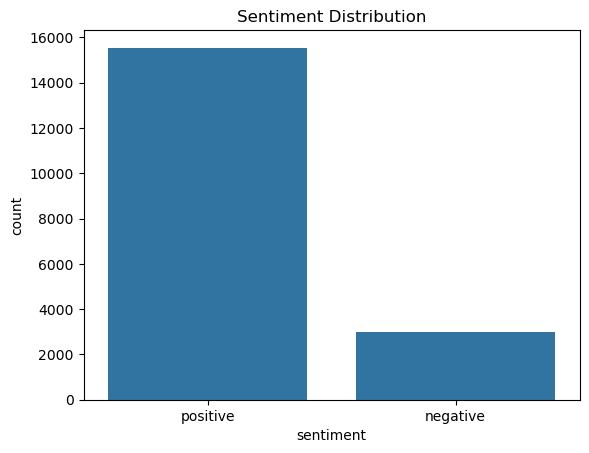

In [11]:
print(df['sentiment'].value_counts())

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

Text Processing

In [12]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

df['clean_review'] = df['Text'].apply(preprocess)

Bag Of Words

In [14]:
#Feature Extraction
cv = CountVectorizer(max_features=5000)

X_cv = cv.fit_transform(df['clean_review'])
y = df['sentiment']

In [15]:
#Train test split
X_train_cv, X_test_cv, y_train, y_test = train_test_split(
    X_cv, y, test_size=0.2, random_state=42
)

In [16]:
#Accuracy
nb_cv = MultinomialNB()
nb_cv.fit(X_train_cv, y_train)

y_pred_cv = nb_cv.predict(X_test_cv)

print("BoW Accuracy:", accuracy_score(y_test, y_pred_cv))

BoW Accuracy: 0.8911987041036717


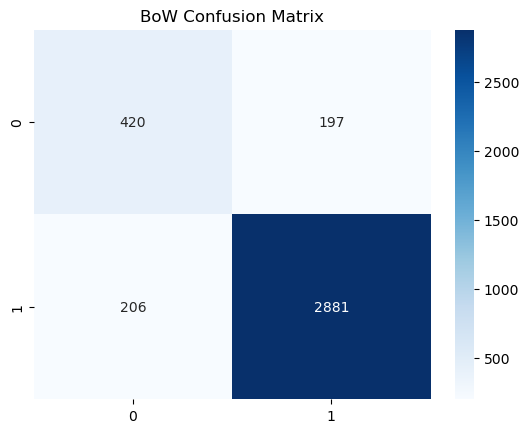

In [17]:
#Confusion Matrix
cm_cv = confusion_matrix(y_test, y_pred_cv)

sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues')
plt.title("BoW Confusion Matrix")
plt.show()

In [18]:
#Classification report
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

    negative       0.67      0.68      0.68       617
    positive       0.94      0.93      0.93      3087

    accuracy                           0.89      3704
   macro avg       0.80      0.81      0.81      3704
weighted avg       0.89      0.89      0.89      3704



TF-IDF

In [20]:
#Feature Extraction
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_review'])

In [21]:
#Train test split
X_train_tf, X_test_tf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [22]:
#Accuracy
nb_tf = MultinomialNB()
nb_tf.fit(X_train_tf, y_train)

y_pred_tf = nb_tf.predict(X_test_tf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tf))

TF-IDF Accuracy: 0.8517818574514039


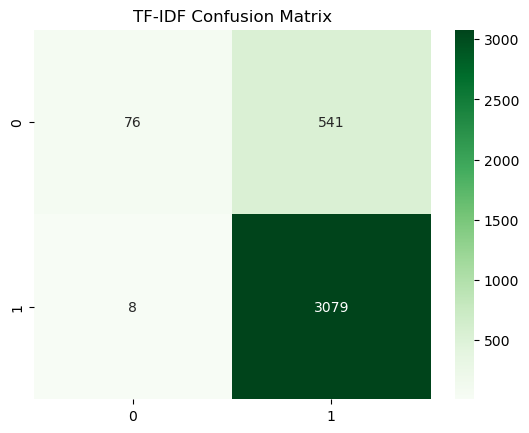

In [23]:
#Confusion Matrix
cm_tf = confusion_matrix(y_test, y_pred_tf)

sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Greens')
plt.title("TF-IDF Confusion Matrix")
plt.show()

In [24]:
#Classification report
print(classification_report(y_test, y_pred_tf))

              precision    recall  f1-score   support

    negative       0.90      0.12      0.22       617
    positive       0.85      1.00      0.92      3087

    accuracy                           0.85      3704
   macro avg       0.88      0.56      0.57      3704
weighted avg       0.86      0.85      0.80      3704



Comparison

In [25]:
print("BoW Accuracy:", accuracy_score(y_test, y_pred_cv))
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tf))

BoW Accuracy: 0.8911987041036717
TF-IDF Accuracy: 0.8517818574514039


Prediction

In [26]:
sample = ["This product is really amazing and tasty"]

sample_clean = preprocess(sample[0])
sample_vector = tfidf.transform([sample_clean])

prediction = nb_tf.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: positive
